In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from sklearn.manifold import MDS 
from sklearn.decomposition import PCA 
from log_kde import log_kde

In [2]:
MarkovChain = "P_matrix_cyclooctane_R144_MSM2.csv"
P_ref = np.loadtxt(f"MarkovChains/{MarkovChain}", delimiter=",")
P_ref = P_ref.astype("float64")

P_ref.shape

(2501, 2501)

$$\log_{kde}(p) = \psi(p) = \log\left(\sum_{i=1}^N c_i \exp(-KL(p \;||\; P_{i, -}))\right)$$

In [3]:
# log kde object to generate R, Q
time = 500
log_kde_obj = log_kde(P_ref, time)

In [4]:
R_mat = log_kde_obj.calculate_R_mat()
Q_mat = log_kde_obj.calculate_Q_mat()

100%|██████████| 2501/2501 [00:02<00:00, 842.83it/s] 


In [5]:
# projection generators
pca = PCA(n_components=3)
mds = MDS(n_components=3)

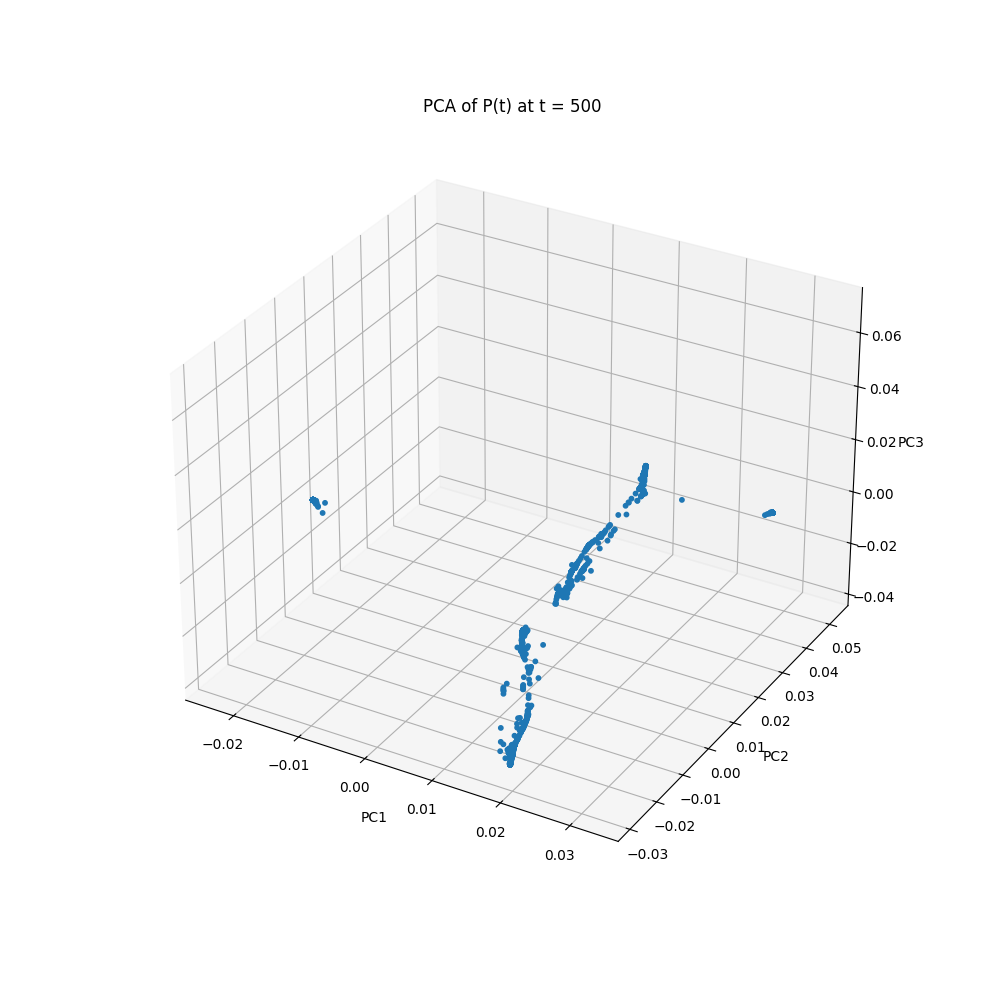

In [6]:
Pt_PCA = pca.fit_transform(log_kde_obj.Pt)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"PCA of P(t) at t = {time}")
# Scatter plot
sc = ax.scatter(
    Pt_PCA[:, 0],
    Pt_PCA[:, 1],
    Pt_PCA[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)


# Optional: labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

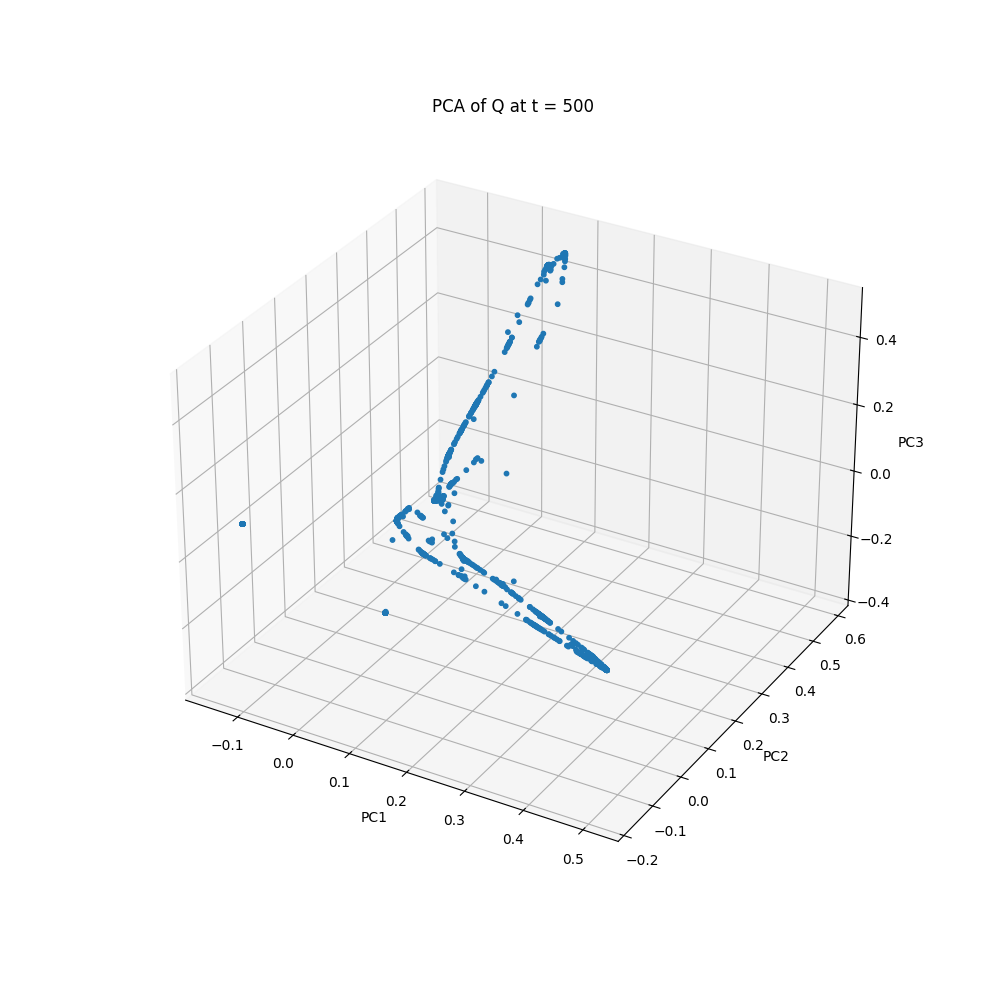

In [7]:
Q_proj_pca = pca.fit_transform(Q_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"PCA of Q at t = {time}")
# Scatter plot
sc = ax.scatter(
    Q_proj_pca[:, 0],
    Q_proj_pca[:, 1],
    Q_proj_pca[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)


# Optional: labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

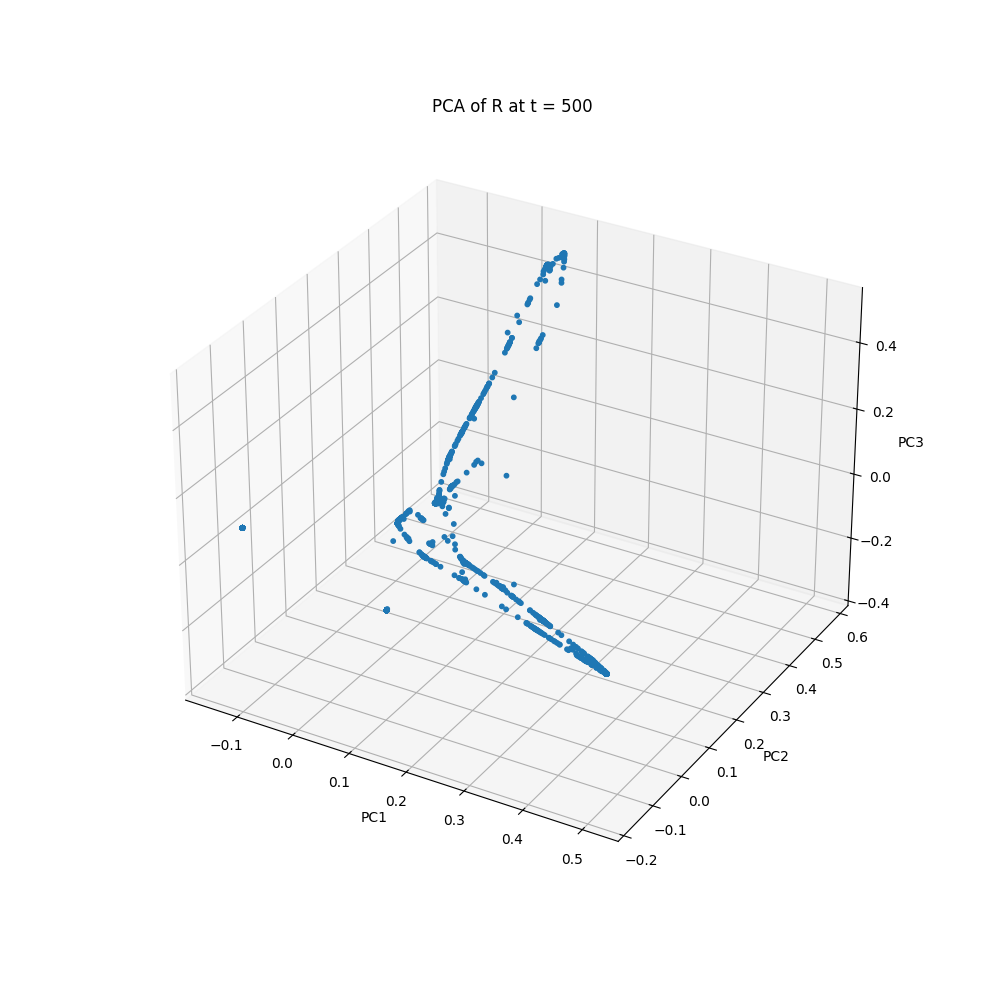

In [8]:
R_proj_pca = pca.fit_transform(R_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"PCA of R at t = {time}")
# Scatter plot
sc = ax.scatter(
    R_proj_pca[:, 0],
    R_proj_pca[:, 1],
    R_proj_pca[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)

# labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

In [9]:
fig = px.scatter_3d(
    title=f"PCA of Q at time = {time}",
    x=Q_proj_pca[:,0],
    y=Q_proj_pca[:,1],
    z=Q_proj_pca[:,2],
    hover_name=np.arange(len(Q_proj_pca)),
    size_max=5
)
fig.update_traces(marker_size=1)
fig.show()

In [10]:
fig = px.scatter_3d(
    title=f"PCA of R at time = {time}",
    x=R_proj_pca[:,0],
    y=R_proj_pca[:,1],
    z=R_proj_pca[:, 2],
    hover_name=np.arange(len(R_proj_pca)),
    size_max=5
)
fig.update_traces(marker_size=1)
fig.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:601: UserWarning:

The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:298: FutureWarning:

The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.



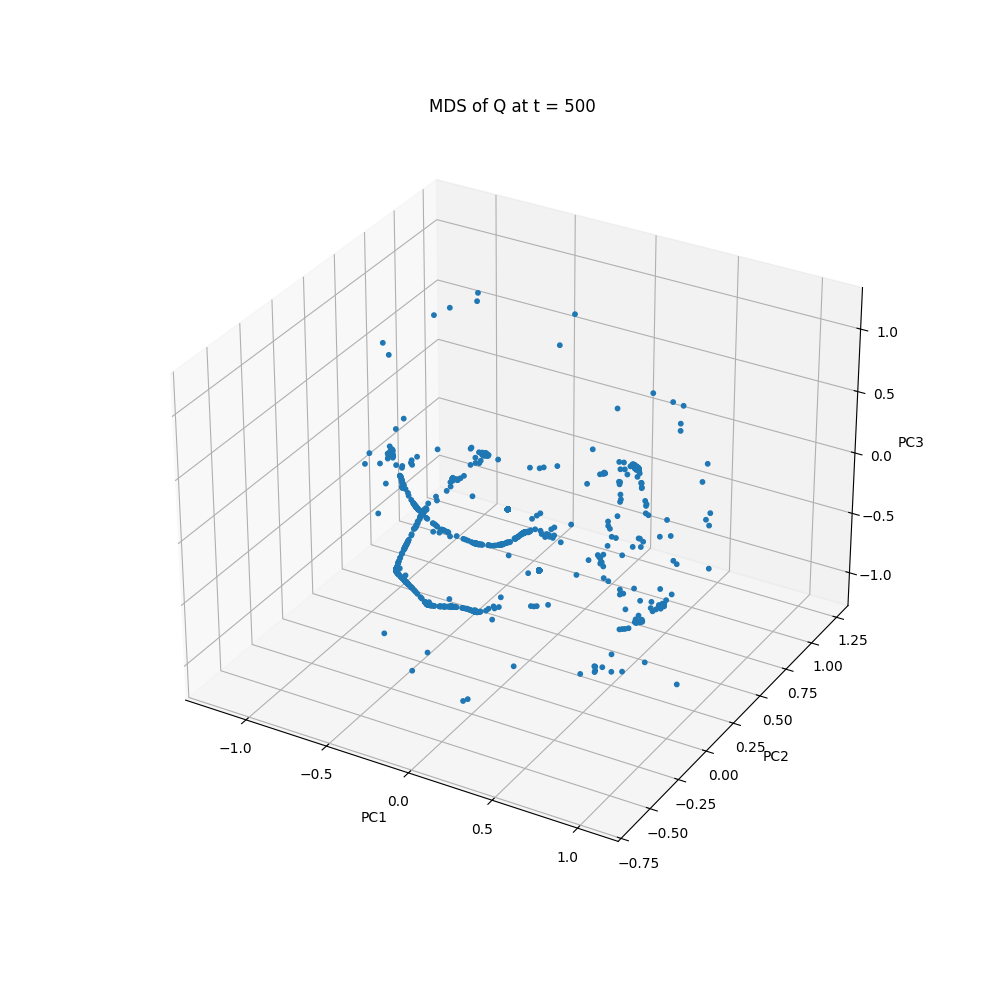

In [11]:
Q_proj_mds = mds.fit_transform(Q_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"MDS of Q at t = {time}")
# Scatter plot
sc = ax.scatter(
    Q_proj_mds[:, 0],
    Q_proj_mds[:, 1],
    Q_proj_mds[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)

# labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:601: UserWarning:

The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:298: FutureWarning:

The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.



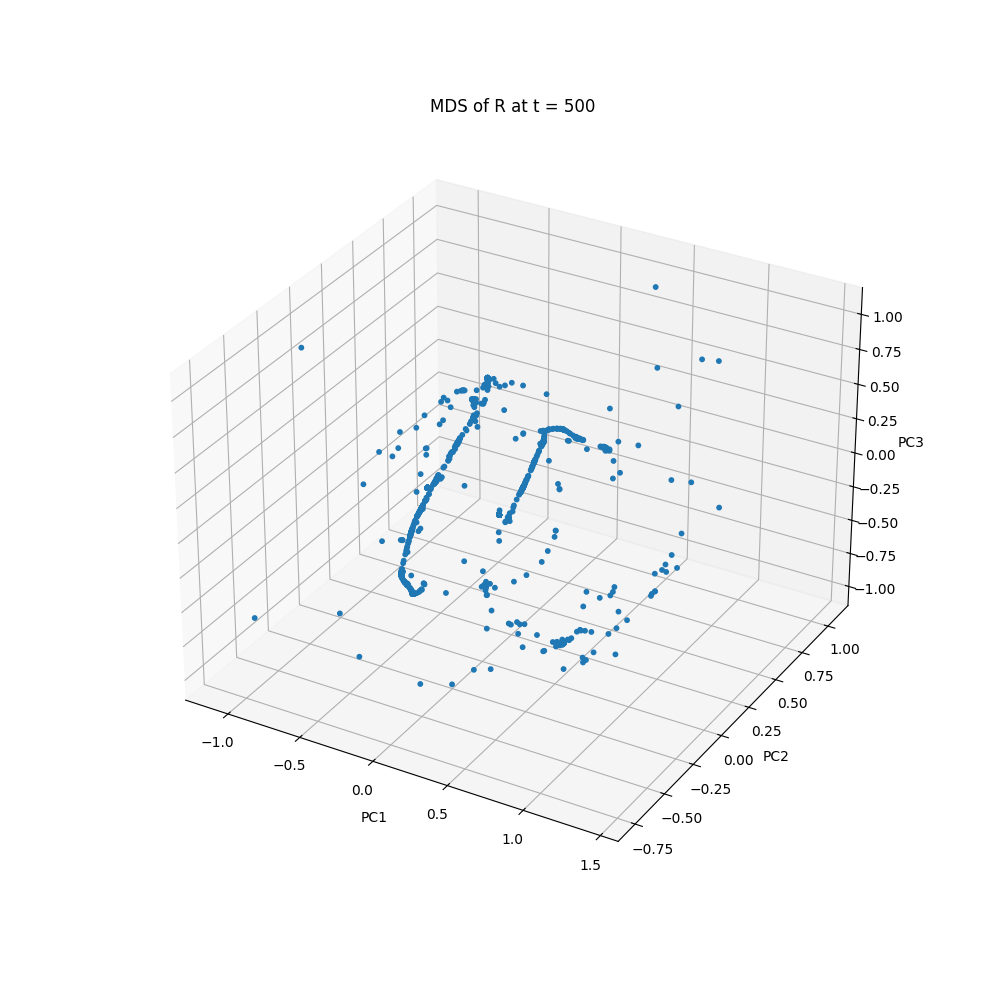

In [12]:
R_proj_mds = mds.fit_transform(R_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"MDS of R at t = {time}")
# Scatter plot
sc = ax.scatter(
    R_proj_mds[:, 0],
    R_proj_mds[:, 1],
    R_proj_mds[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)

# Optional: labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()

In [13]:
import plotly.express as px

fig = px.scatter_3d(
    title=f"MDS of Q at time = {time}",
    x=Q_proj_mds[:,0],
    y=Q_proj_mds[:,1],
    z=Q_proj_mds[:,2],
    hover_name=np.arange(len(Q_proj_mds)),
)

fig.show()

In [14]:
import plotly.express as px

fig = px.scatter_3d(
    title=f"MDS of R at time = {time}",
    x=R_proj_mds[:,0],
    y=R_proj_mds[:,1],
    z=R_proj_mds[:,2],
    hover_name=np.arange(len(R_proj_mds)),
    size_max=5
)

fig.show()